
# Install conda and necessary packages



In [4]:
!pip install -q condacolab

In [1]:
import condacolab
condacolab.install()

✨🍰✨ Everything looks OK!


In [1]:
!pip install git+https://github.com/Teoroo-CMC/CCS.git@Towards-version-1.0

  Cloning https://github.com/Teoroo-CMC/CCS.git (to revision Towards-version-1.0) to /tmp/pip-req-build-nx5i3bxu
  Running command git clone --filter=blob:none --quiet https://github.com/Teoroo-CMC/CCS.git /tmp/pip-req-build-nx5i3bxu
  Running command git checkout -b Towards-version-1.0 --track origin/Towards-version-1.0
  Switched to a new branch 'Towards-version-1.0'
  Branch 'Towards-version-1.0' set up to track remote branch 'Towards-version-1.0' from 'origin'.
  Resolved https://github.com/Teoroo-CMC/CCS.git to commit c07c633450424ecbd1e2ea02af31536eedf1b152
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.3/72.3 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 610.4/610.4 kB 14.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 63.9 MB/s eta 0:00:00
  Created wheel for ccs_fit: filename=ccs_fit-1.0.0-py3-n

In [2]:
!conda install -n base mamba dftbplus dftbplus-tools


Channels:
 - conda-forge
Platform: linux-64
Solving environment: / - \ | done

## Package Plan ##

  environment location: /usr/local

  added / updated specs:
    - dftbplus
    - dftbplus-tools
    - mamba


The following packages will be downloaded:

    package                    |            build
    ---------------------------|-----------------
    arpack-3.9.1               |nompi_hf03ea27_102         127 KB  conda-forge
    c-ares-1.34.6              |       hb03c661_0         203 KB  conda-forge
    ca-certificates-2026.2.25  |       hbd8a1cb_0         144 KB  conda-forge
    certifi-2026.2.25          |     pyhd8ed1ab_0         148 KB  conda-forge
    chimes-calculator-1.0.2    |       h0c14de7_0         185 KB  conda-forge
    conda-26.1.1               |  py311h38be061_0         1.2 MB  conda-forge
    conda-libmamba-solver-25.11.0|     pyhd8ed1ab_1          56 KB  conda-forge
    cpp-expected-1.3.1         |       h171cf75_0          24 KB  conda-forge
    dftbplu

In [3]:
import os
os.chdir('/content')
!git clone https://github.com/drdamia/DFTB-.git

Cloning into 'DFTB-'...
remote: Enumerating objects: 359, done.
remote: Counting objects: 100% (15/15), done.
remote: Compressing objects: 100% (5/5), done.
remote: Total 359 (delta 10), reused 10 (delta 10), pack-reused 344 (from 2)
Receiving objects: 100% (359/359), 15.27 MiB | 17.75 MiB/s, done.
Resolving deltas: 100% (166/166), done.


# Obtain electronic structure with generated SK-files

In [4]:
%env DFTB_PREFIX='/content/DFTB-/SKFS/'
%env ASE_DFTB_COMMAND="dftb+"

env: DFTB_PREFIX='/content/DFTB-/SKFS/'
env: ASE_DFTB_COMMAND="dftb+"


In [8]:
from logging import Handler
from ase.io import read,write
from ase.calculators.dftb import Dftb
from ase.db import connect
db = connect('/content/DFTB.db')


calc_LFP = Dftb(Hamiltonian_='DFTB',  # this line is included by default
            Hamiltonian_Scc='Yes',
            Hamiltonian_SCCTolerance=1e-4,
            Hamiltonian_MaxSccIterations='1200',
            Hamiltonian_Mixer_='Broyden',
            Hamiltonian_Mixer_MixingParameter='0.25',
            Hamiltonian_SpinPolarisation_='Colinear',
            Hamiltonian_SpinPolarisation_UnpairedElectrons='16',
            Hamiltonian_SpinConstants_='',
            Hamiltonian_SpinConstants_Li='{-0.035 -0.030 -0.030 -0.028}',
            Hamiltonian_SpinConstants_Fe='{-0.016 -0.012 -0.003 -0.012 -0.029 -0.001 -0.003 -0.001 -0.015}',
            Hamiltonian_SpinConstants_O='{-0.035 -0.030 -0.030 -0.028}',
            Hamiltonian_SpinConstants_P='{-0.035 -0.030 -0.030 -0.028}',
            Hamiltonian_MaxAngularMomentum_='',
            Hamiltonian_OrbitalPotential_='',
            Hamiltonian_OrbitalPotential_Functional='{FLL}',
            Hamiltonian_OrbitalPotential_Fe_='',
            Hamiltonian_OrbitalPotential_Fe_shells='{3}',
            Hamiltonian_OrbitalPotential_Fe_UJ='0.10',
            Hamiltonian_MaxAngularMomentum_Li='p',
            Hamiltonian_MaxAngularMomentum_Fe='d',
            Hamiltonian_MaxAngularMomentum_P='p',
            Hamiltonian_MaxAngularMomentum_O='p',
            Hamiltonian_KPointsAndWeights = 'SupercellFolding {1 0 0 0 1 0 0 0 1 0.0 0.0 0.0}')

calc_FP  =  Dftb(Hamiltonian_='DFTB',  # this line is included by default
            Hamiltonian_Scc='Yes',
            Hamiltonian_SCCTolerance=1e-4,
            Hamiltonian_MaxSccIterations='1200',
            Hamiltonian_Mixer_='Broyden',
            Hamiltonian_Mixer_MixingParameter='0.25',
            Hamiltonian_SpinPolarisation_='Colinear',
            Hamiltonian_SpinPolarisation_UnpairedElectrons='20',
            Hamiltonian_SpinConstants_='',
            Hamiltonian_SpinConstants_Fe='{-0.016 -0.012 -0.003 -0.012 -0.029 -0.001 -0.003 -0.001 -0.015}',
            Hamiltonian_SpinConstants_O='{-0.035 -0.030 -0.030 -0.028}',
            Hamiltonian_SpinConstants_P='{-0.035 -0.030 -0.030 -0.028}',
            Hamiltonian_MaxAngularMomentum_='',
            Hamiltonian_OrbitalPotential_='',
            Hamiltonian_OrbitalPotential_Functional='{FLL}',
            Hamiltonian_OrbitalPotential_Fe_='',
            Hamiltonian_OrbitalPotential_Fe_shells='{3}',
            Hamiltonian_OrbitalPotential_Fe_UJ='0.10',
            Hamiltonian_MaxAngularMomentum_Fe='d',
            Hamiltonian_MaxAngularMomentum_P='p',
            Hamiltonian_MaxAngularMomentum_O='p',
            Hamiltonian_KPointsAndWeights = 'SupercellFolding {1 0 0 0 1 0 0 0 1 0.0 0.0 0.0}')


ats = read('/content/DFTB-/train.db',':')
ats_dftb=[]
ats_dft=[]
for i,at in enumerate(ats):
    print("Structure No:",i)
    if 'Li' in at.symbols:
        at.calc=calc_LFP
    else:
        at.calc=calc_FP

    at.get_potential_energy()
    at.get_forces()
    ats_dftb.append(at)
    db.write(at, idx=i)



Structure No: 0
Structure No: 1
Structure No: 2
Structure No: 3
Structure No: 4
Structure No: 5
Structure No: 6
Structure No: 7
Structure No: 8
Structure No: 9
Structure No: 10
Structure No: 11
Structure No: 12
Structure No: 13
Structure No: 14
Structure No: 15
Structure No: 16
Structure No: 17
Structure No: 18
Structure No: 19
Structure No: 20
Structure No: 21
Structure No: 22
Structure No: 23
Structure No: 24
Structure No: 25
Structure No: 26
Structure No: 27
Structure No: 28
Structure No: 29
Structure No: 30
Structure No: 31
Structure No: 32
Structure No: 33
Structure No: 34
Structure No: 35
Structure No: 36
Structure No: 37
Structure No: 38
Structure No: 39
Structure No: 40
Structure No: 41


In [54]:
import json
from ccs_fit.fitting.main import twp_fit as ccs_fit
input={
        "General": {
                "Interface": "DFTB",
                "FitForces": "True",
                "DoUnconstrainedFit": "True",
        },
        "TrainSet": "/content/DFTB-/train.db",
        "TrainSetDFTB": "/content/DFTB.db",
                "Twobody": {
                "Xx-Xx": {
                        "Rcut": 3.5,
                        "Resolution": 0.05,
                        "SwType": "rep",
                        "ConstType": "Mono"
                },
                "O-P": {
                        "Rcut": 3.5,
                        "Resolution": 0.05,
                        "SwType": "sw",
                        "ConstType": "Mono"
                },
        },
}

#SAVE TO FILE
with open('CCS_input.json', 'w') as f:
    json.dump(input, f, indent=8)

#RUN FIT
ccs_fit("CCS_input.json")

No range separation applied.


    Fetching data: 100%|██████████| 42/42 [00:00<00:00, 60.51it/s]


    Generating one-body information from training-set.
        Added elements:  ['Fe', 'Li', 'O', 'P']
    Generating two-body potentials from one-body information.
    Adding pair: Fe-Fe
    Adding pair: Fe-Li
    Adding pair: Fe-O
    Adding pair: Fe-P
    Adding pair: Li-Li
    Adding pair: Li-O
    Adding pair: Li-P
    Adding pair: O-O
    Adding pair: P-P
    Applying monotonic constraints for pair:  O-P
    Applying monotonic constraints for pair:  Fe-Fe
    Applying monotonic constraints for pair:  Fe-Li
    Applying monotonic constraints for pair:  Fe-O
    Applying monotonic constraints for pair:  Fe-P
    Applying monotonic constraints for pair:  Li-Li
    Applying monotonic constraints for pair:  Li-O
    Applying monotonic constraints for pair:  Li-P
    Applying monotonic constraints for pair:  O-O
    Applying monotonic constraints for pair:  P-P
    Merging intervals for pair O-P; number of intervals reduced from 47 to 32. 
    Merging intervals for pair Fe-Fe; number o

/usr/local/lib/python3.12/dist-packages/ccs_fit/fitting/spline_functions.py:494: RuntimeWarning: invalid value encountered in log
  beta = alpha * r0 + np.log(cc / alpha**2)


    Merging intervals for pair O-P; number of intervals reduced from 47 to 32. 
    Merging intervals for pair Fe-Fe; number of intervals reduced from 6 to 5. 
    Merging intervals for pair Fe-O; number of intervals reduced from 39 to 36. 
    Merging intervals for pair Li-O; number of intervals reduced from 36 to 30. 
    Merging intervals for pair Li-P; number of intervals reduced from 26 to 24. 
--- CONSTRAINED FIT ---


    Finding optimum switch: 100%|██████████| 33/33 [00:00<00:00, 46.59it/s]

    The best switch is [14, 5, 15, 36, 23, 21, 30, 24, 31, 10] with objective: 9.2464, corresponding to distances of [1.9  3.48 3.46 3.47 3.46 3.49 3.49 3.48 3.47 3.47] Å for element pairs ['O-P', 'Fe-Fe', 'Fe-Li', 'Fe-O', 'Fe-P', 'Li-Li', 'Li-O', 'Li-P', 'O-O', 'P-P'].
    P is positive definite. The minimizer is unique.
    MSE of constrained problem is:  0.11704301840551519


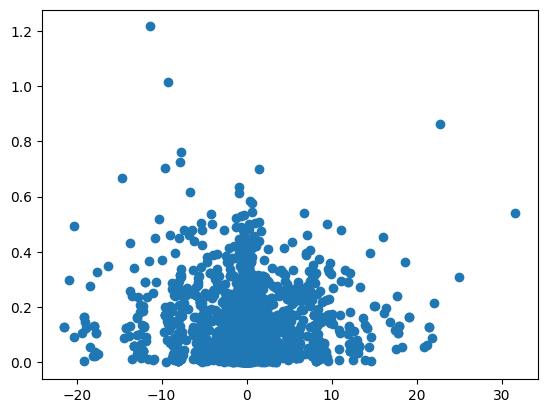

In [59]:
import matplotlib.pyplot as plt
import numpy as np

err=np.loadtxt("UNC_error_forces.out")
plt.scatter(err[:,0],err[:,2])

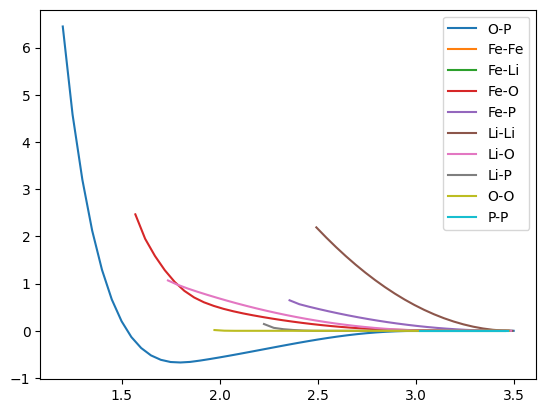

In [56]:
import matplotlib.pyplot as plt
import numpy as np
import json

with open("CCS_params.json","r") as f:
  data=json.load(f)


for pair in data['Two_body']:
  plt.plot(data['Two_body'][pair]["r"],data['Two_body'][pair]["spl_a"],label=pair)

plt.legend()

In [62]:
!tail CCS_error_energies.out

1777.56270      1776.82692      0.73578         24.00000       
1763.58436      1763.94281      0.35845         24.00000       
1777.75118      1776.92739      0.82379         24.00000       
1812.99053      1812.74449      0.24603         24.00000       
1763.60737      1763.93877      0.33140         24.00000       
1768.91892      1768.62275      0.29617         24.00000       
1812.90712      1812.58931      0.31781         24.00000       
1845.92738      1846.71890      0.79153         24.00000       
# MSE = 8.20192E-01
# Maxerror = 2.14205E+00
